In [1]:
# --- Cell 1: imports + config ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from shared.pacs import CLASSES
from shared.pacs_protocol import build_loaders
from task2.backbones.backbone import PACSModel
from task2.training.train_loop import train_model
from task2.evaluations.metrics import evaluate_loader, evaluate_source_val
from task2.evaluations.class_analysis import per_class_table, predicted_distribution
from task3.methods.dan_dg import DAN_DG
from task3.evaluations.source_domain_separability import (collect_source_features,
                                                          source_domain_separability)
from task3.evaluations.sharpness import fixed_val_batch, sharpness_proxy

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE = dict(seed=6304, num_classes=7,
            batch_per_source=8, eval_batch=64, num_workers=0,
            max_epochs=30, patience=5, lr=1e-4, weight_decay=1e-4, amp=False)
LAMBDAS = [0.1, 10.0]          # lambda_DG = 1 is the main run, already trained
DATA_ROOT = '../../datasets/PACS'
splits = load_results('../../shared/splits/pacs_sketch_seed6304.json')

In [2]:
# --- Cell 2: train the two extra lambdas---
runs = {}
for lam in LAMBDAS:
    cfg = dict(BASE, lambda_dg=lam)
    tag = f"dan_dg_lam{lam}"
    print(f"\n===== {tag} =====")
    set_seed(6304)
    loaders = build_loaders(DATA_ROOT, splits,          # rebuild per run: fixed order
                            batch_per_source=cfg['batch_per_source'],
                            eval_batch=cfg['eval_batch'],
                            num_workers=cfg['num_workers'], seed=cfg['seed'],
                            include_target=False)       # training never sees Sketch
    assert loaders['target_train'] is None
    model = PACSModel(num_classes=7).to(device)
    method = DAN_DG(cfg)
    out = train_model(model, method, loaders, cfg, device,
                      ckpt_path=f'../../datasets/cache/task3_{tag}.pt')
    runs[lam] = {'config': cfg, 'best_epoch': out['best_epoch'],
                 'best_mean_macro_f1': out['best_mean_macro_f1'],
                 'source_val_at_best': out['source_val_at_best'],
                 'minutes': out['minutes'], 'history': out['history']}
    print(tag, out['best_epoch'], round(out['best_mean_macro_f1'], 4))


===== dan_dg_lam0.1 =====
ep01 loss_total=0.5947 loss_cls=0.5371 loss_mmd=0.5767 mmd_pa=0.5563 mmd_pc=0.5966 mmd_ac=0.5772 train_acc=0.8157 | val photo=0.931 art_painting=0.837 cartoon=0.905 mean_f1=0.8911 | 33s
ep02 loss_total=0.2579 loss_cls=0.2058 loss_mmd=0.5212 mmd_pa=0.5132 mmd_pc=0.5255 mmd_ac=0.5250 train_acc=0.9349 | val photo=0.966 art_painting=0.858 cartoon=0.936 mean_f1=0.9199 | 67s
ep03 loss_total=0.1917 loss_cls=0.1419 loss_mmd=0.4981 mmd_pa=0.4896 mmd_pc=0.4987 mmd_ac=0.5060 train_acc=0.9505 | val photo=0.938 art_painting=0.813 cartoon=0.917 mean_f1=0.8893 | 101s
ep04 loss_total=0.1541 loss_cls=0.1040 loss_mmd=0.5018 mmd_pa=0.4759 mmd_pc=0.5184 mmd_ac=0.5111 train_acc=0.9667 | val photo=0.956 art_painting=0.894 cartoon=0.946 mean_f1=0.9320 | 135s
ep05 loss_total=0.1266 loss_cls=0.0784 loss_mmd=0.4821 mmd_pa=0.4734 mmd_pc=0.4837 mmd_ac=0.4893 train_acc=0.9752 | val photo=0.965 art_painting=0.910 cartoon=0.941 mean_f1=0.9386 | 168s
ep06 loss_total=0.1098 loss_cls=0.0602 l

In [3]:
# --- Cell 3: evaluate all three lambdas ---
loaders = build_loaders(DATA_ROOT, splits, batch_per_source=8, target_batch=24,
                        eval_batch=64, num_workers=0, seed=6304, include_target=True)
xb, yb = fixed_val_batch(loaders['source_val'], device, per_domain=32, seed=6304)

CKPTS = {0.1: '../../datasets/cache/task3_dan_dg_lam0.1.pt',
         1.0: '../../datasets/cache/task3_dan_dg.pt',        # the main run
         10.0: '../../datasets/cache/task3_dan_dg_lam10.0.pt'}

sweep = {}
for lam, path in CKPTS.items():
    ck = torch.load(path, map_location=device, weights_only=False)
    model = PACSModel(num_classes=7).to(device)
    model.load_state_dict(ck['model'])

    sv = evaluate_source_val(model, loaders['source_val'], device)
    f1s = [v['macro_f1'] for v in sv['per_domain'].values()]
    tg = evaluate_loader(model, loaders['target_eval'], device)
    feats, doms, _ = collect_source_features(model, loaders['source_val'], device)
    sep = source_domain_separability(feats, doms, seed=6304)
    sharp = sharpness_proxy(model, xb, yb, rho=0.05)

    sweep[lam] = {'best_epoch': ck['best_epoch'],
                  'src_mean_f1': sv['mean_macro_f1'], 'worst_f1': float(min(f1s)),
                  'sketch_acc': tg['accuracy'], 'sketch_f1': tg['macro_f1'],
                  'separability': sep['separability'],
                  'sharpness': sharp['delta_sharp'],
                  'per_class': per_class_table(tg['preds'], tg['labels'], CLASSES),
                  'pred_counts': predicted_distribution(tg['preds'], CLASSES)}
    print(f"lam={lam:<5} ep={ck['best_epoch']:<3} src_f1={sv['mean_macro_f1']:.4f} "
          f"worst={min(f1s):.4f} sketch_acc={tg['accuracy']:.4f} "
          f"sketch_f1={tg['macro_f1']:.4f} sep={sep['separability']:.4f} "
          f"sharp={sharp['delta_sharp']:+.4f}")

lam=0.1   ep=26  src_f1=0.9568 worst=0.9399 sketch_acc=0.6903 sketch_f1=0.7063 sep=0.6013 sharp=+0.1443
lam=1.0   ep=1   src_f1=0.0507 worst=0.0421 sketch_acc=0.0407 sketch_f1=0.0112 sep=0.3322 sharp=+0.0352
lam=10.0  ep=1   src_f1=0.0507 worst=0.0421 sketch_acc=0.0407 sketch_f1=0.0112 sep=0.4419 sharp=+0.0280


 lambda_DG  best_epoch  src_mean_f1  worst_f1  sketch_acc  sketch_f1  src_separability  sharpness
       0.1          26       0.9568    0.9399      0.6903     0.7063            0.6013     0.1443
       1.0           1       0.0507    0.0421      0.0407     0.0112            0.3322     0.0352
      10.0           1       0.0507    0.0421      0.0407     0.0112            0.4419     0.0280

predicted-label counts (support: house 80, person 160)
  lam=0.1   {'dog': 969, 'elephant': 784, 'giraffe': 672, 'guitar': 485, 'horse': 529, 'house': 76, 'person': 414}
  lam=1.0   {'dog': 0, 'elephant': 0, 'giraffe': 0, 'guitar': 0, 'horse': 0, 'house': 0, 'person': 3929}
  lam=10.0  {'dog': 0, 'elephant': 0, 'giraffe': 0, 'guitar': 0, 'horse': 0, 'house': 0, 'person': 3929}


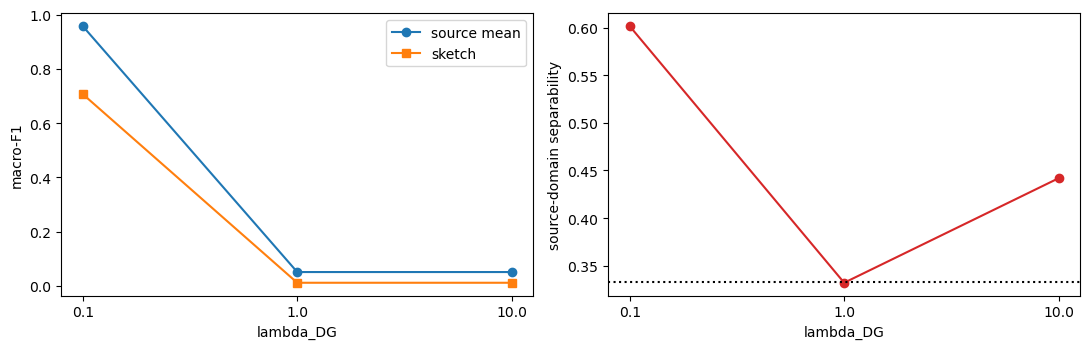

In [4]:
# --- Cell 4: required compact table + figure ---
import pandas as pd, matplotlib.pyplot as plt
rows = [{'lambda_DG': lam, 'best_epoch': s['best_epoch'],
         'src_mean_f1': round(s['src_mean_f1'], 4), 'worst_f1': round(s['worst_f1'], 4),
         'sketch_acc': round(s['sketch_acc'], 4), 'sketch_f1': round(s['sketch_f1'], 4),
         'src_separability': round(s['separability'], 4),
         'sharpness': round(s['sharpness'], 4)}
        for lam, s in sorted(sweep.items())]
print(pd.DataFrame(rows).to_string(index=False))
print('\npredicted-label counts (support: house 80, person 160)')
for lam, s in sorted(sweep.items()):
    print(f"  lam={lam:<5}", s['pred_counts'])

lams = sorted(sweep); x = np.arange(len(lams))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(x, [sweep[l]['src_mean_f1'] for l in lams], marker='o', label='source mean')
ax[0].plot(x, [sweep[l]['sketch_f1'] for l in lams], marker='s', label='sketch')
ax[0].set_ylabel('macro-F1'); ax[0].legend()
ax[1].plot(x, [sweep[l]['separability'] for l in lams], marker='o', color='tab:red')
ax[1].axhline(1/3, ls=':', c='k'); ax[1].set_ylabel('source-domain separability')
for a in ax:
    a.set_xticks(x); a.set_xticklabels([str(l) for l in lams]); a.set_xlabel('lambda_DG')
plt.tight_layout(); plt.savefig('../../report/figures/task3_lambda_study.png', dpi=200)
plt.show()

In [5]:
# --- Cell 5: save ---
save_results({'step': 'task3_lambda_study', 'seed': 6304, 'method': 'dan_dg',
              'table': rows,
              'lambdas': {str(k): v for k, v in sweep.items()},
              'training': {str(k): v for k, v in runs.items()}},
             '../results/lambda_study.json')
print('saved')

saved
